In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random


In [ ]:
torch.manual_seed(0)
random.seed(0)

vocab_size = 3
seq_len = 3
hidden_size = 40
num_epochs = 1000

def generate_sample():
    tokens = [random.randint(0, vocab_size - 1) for _ in range(seq_len)]
    x = F.one_hot(torch.tensor(tokens), num_classes=vocab_size).float().unsqueeze(0)
    y = torch.tensor(tokens).unsqueeze(0)
    return x, y

class RNN_AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.RNN(vocab_size, hidden_size, batch_first=True)
        self.decoder = nn.RNN(vocab_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        _, h = self.encoder(x)
        dec_input = torch.zeros((1, 1, vocab_size))
        outputs = []
        for _ in range(seq_len):
            dec_out, h = self.decoder(dec_input, h)
            logits = self.out(dec_out)
            outputs.append(logits)
            dec_input = logits.detach()
        return torch.cat(outputs, dim=1)

model = RNN_AE()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range(num_epochs):
    x, y = generate_sample()
    logits = model(x)
    loss = sum(criterion(logits[:, t], y[:, t]) for t in range(seq_len)) / seq_len
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        pred = logits.argmax(dim=2)
        print(f"Epoch {epoch}: Loss={loss.item():.4f}, Predicted={pred.tolist()}, Target={y.tolist()}")


Epoch 0: Loss=1.1661, Predicted=[[2, 2, 2]], Target=[[1, 1, 0]]
Epoch 50: Loss=0.5093, Predicted=[[1, 0, 0]], Target=[[1, 0, 0]]
Epoch 100: Loss=0.0473, Predicted=[[2, 0, 1]], Target=[[2, 0, 1]]
Epoch 150: Loss=0.1826, Predicted=[[2, 1, 2]], Target=[[2, 1, 2]]
Epoch 200: Loss=0.0107, Predicted=[[1, 1, 1]], Target=[[1, 1, 1]]
Epoch 250: Loss=0.0366, Predicted=[[2, 0, 2]], Target=[[2, 0, 2]]
Epoch 300: Loss=0.0051, Predicted=[[0, 2, 1]], Target=[[0, 2, 1]]
Epoch 350: Loss=0.0628, Predicted=[[2, 2, 0]], Target=[[2, 2, 0]]
Epoch 400: Loss=0.0052, Predicted=[[0, 0, 1]], Target=[[0, 0, 1]]
Epoch 450: Loss=0.0029, Predicted=[[1, 1, 0]], Target=[[1, 1, 0]]
Epoch 500: Loss=0.0014, Predicted=[[1, 2, 1]], Target=[[1, 2, 1]]
Epoch 550: Loss=0.0062, Predicted=[[0, 0, 2]], Target=[[0, 0, 2]]
Epoch 600: Loss=0.0040, Predicted=[[0, 1, 0]], Target=[[0, 1, 0]]
Epoch 650: Loss=0.0008, Predicted=[[0, 2, 1]], Target=[[0, 2, 1]]
Epoch 700: Loss=0.0007, Predicted=[[0, 2, 1]], Target=[[0, 2, 1]]
Epoch 750: Lo

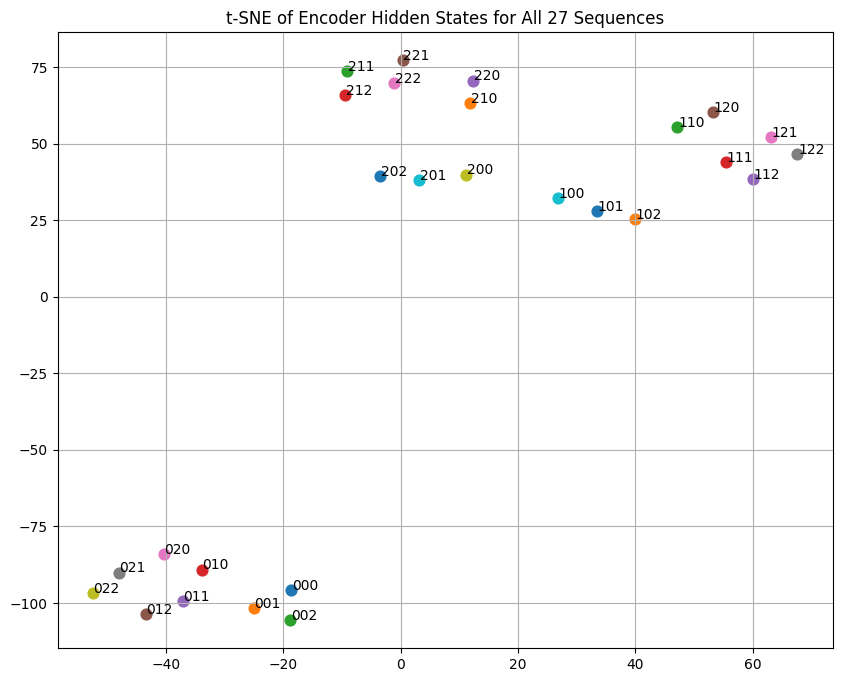

In [16]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import itertools

# Step 1: Generate all 27 sequences
sequences = list(itertools.product(range(3), repeat=3))

# Step 2–3: Run through encoder and collect hidden states
hidden_codes = []
labels = []
model.eval()
with torch.no_grad():
    for seq in sequences:
        x = F.one_hot(torch.tensor(seq), num_classes=3).float().unsqueeze(0)  # (1, 3, 3)
        _, h = model.encoder(x)
        hidden_codes.append(h[0,0].numpy())  # extract (H,) from (1,1,H)
        labels.append("".join(map(str, seq)))

# Step 4: Reduce dimension
hidden_codes = torch.tensor(hidden_codes)
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
embeddings = tsne.fit_transform(hidden_codes)

# Step 5: Plot
plt.figure(figsize=(10, 8))
for i, txt in enumerate(labels):
    plt.scatter(embeddings[i,0], embeddings[i,1], s=60)
    plt.text(embeddings[i,0]+0.1, embeddings[i,1]+0.1, txt, fontsize=10)
plt.title("t-SNE of Encoder Hidden States for All 27 Sequences")
plt.grid(True)
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random

# Hyperparameters
vocab_size = 3          # Tokens: 0,1,2 (for 1,2,3)
embedding_dim = 8
hidden_size = 40
seq_len = 3
batch_size = 1
num_epochs = 1000

# Model
class RNNEncoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True)
    
    def forward(self, x):
        embedded = self.embedding(x)
        out, h = self.rnn(embedded)
        return h  # Return final hidden state

class RNNDecoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x, h):
        embedded = self.embedding(x)
        out, _ = self.rnn(embedded, h)
        return self.fc(out)  # shape: [batch, seq_len, vocab_size]

# Full Autoencoder
class RNNAutoencoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.encoder = RNNEncoder(vocab_size, embedding_dim, hidden_size)
        self.decoder = RNNDecoder(vocab_size, embedding_dim, hidden_size)
    
    def forward(self, x, decoder_input):
        h = self.encoder(x)
        output = self.decoder(decoder_input, h)
        return output

# Instantiate model
model = RNNAutoencoder(vocab_size, embedding_dim, hidden_size)
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

# Training loop
for epoch in range(num_epochs):
    batch = []
    targets = []
    for _ in range(batch_size):
        seq = [random.randint(0, vocab_size - 1) for _ in range(seq_len)]
        batch.append(seq)
        targets.append(seq)

    x = torch.tensor(batch, dtype=torch.long)
    y_true = torch.tensor(targets, dtype=torch.long)

    # Shift decoder input by one (teacher forcing with <sos>=0)
    decoder_input = torch.cat([torch.zeros((batch_size, 1), dtype=torch.long), x[:, :-1]], dim=1)

    optimizer.zero_grad()
    y_pred = model(x, decoder_input)
    loss = loss_fn(y_pred.view(-1, vocab_size), y_true.view(-1))
    loss.backward()
    optimizer.step()

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Epoch 50, Loss: 0.4495
Epoch 100, Loss: 0.9207
Epoch 150, Loss: 0.4562
Epoch 200, Loss: 0.5180
Epoch 250, Loss: 1.7551
Epoch 300, Loss: 0.3702
Epoch 350, Loss: 0.4228
Epoch 400, Loss: 0.4825
Epoch 450, Loss: 0.2549
Epoch 500, Loss: 0.5995
Epoch 550, Loss: 0.5301
Epoch 600, Loss: 0.5380
Epoch 650, Loss: 0.2080
Epoch 700, Loss: 0.5829
Epoch 750, Loss: 0.0078
Epoch 800, Loss: 0.0373
Epoch 850, Loss: 0.1165
Epoch 900, Loss: 1.1797
Epoch 950, Loss: 0.0329
Epoch 1000, Loss: 0.1267


In [53]:
y_true

tensor([[0, 2, 1]])

In [55]:
decoder_input

tensor([[0, 0, 2]])

In [41]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visualize_hidden_states(model, vocab_size=3, seq_len=3, method='pca'):
    model.eval()
    all_seqs = []
    all_hidden_states = []

    # Generate all 27 possible sequences of length 3
    from itertools import product
    sequences = list(product(range(vocab_size), repeat=seq_len))

    for seq in sequences:
        x = torch.tensor(seq, dtype=torch.long).unsqueeze(0)  # shape [1, seq_len]
        with torch.no_grad():
            h = model.encoder(x)  # shape [1, 1, hidden_size]
        all_hidden_states.append(h.squeeze().numpy())
        all_seqs.append("".join(str(s+1) for s in seq))  # label as string e.g., '123'

    X = np.array(all_hidden_states)

    # Reduce to 2D
    if method == 'tsne':
        reducer = TSNE(n_components=2, perplexity=5, init='random', random_state=42)
    else:
        reducer = PCA(n_components=2)
    
    X_2d = reducer.fit_transform(X)

    # Plot
    plt.figure(figsize=(8, 6))
    for i, (x, y) in enumerate(X_2d):
        plt.scatter(x, y, c='blue')
        plt.text(x + 0.1, y, all_seqs[i], fontsize=9)
    
    plt.title(f"Hidden State Representation ({method.upper()})")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


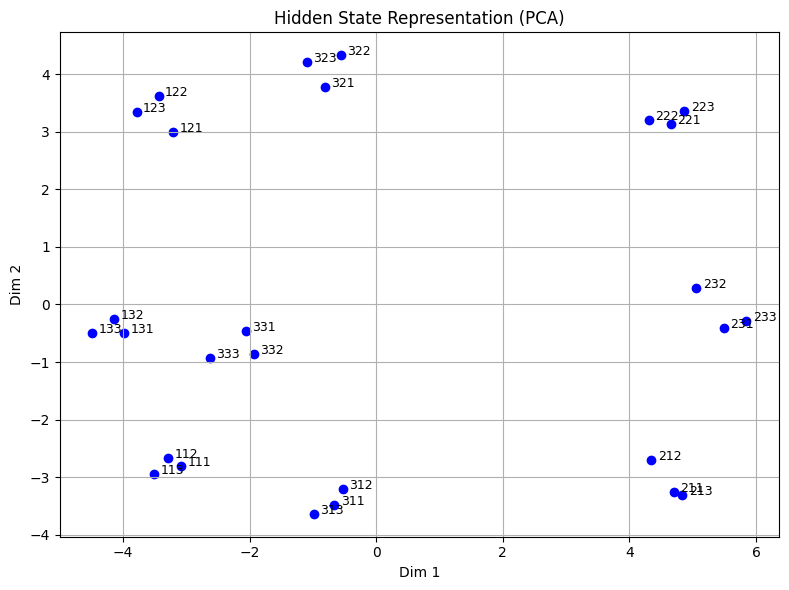

In [42]:
visualize_hidden_states(model)

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from itertools import product

# Hyperparameters
vocab_size = 3          # Tokens: 0,1,2 (representing 1,2,3)
embedding_dim = 8
hidden_size = 40
seq_len = 3             # window size
long_seq_len = 20       # total length of sequence
num_epochs = 1000

# Model
class RNNEncoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True)
    
    def forward(self, x):
        embedded = self.embedding(x)
        _, h = self.rnn(embedded)
        return h  # final hidden state

class RNNDecoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x, h):
        embedded = self.embedding(x)
        out, _ = self.rnn(embedded, h)
        return self.fc(out)

class RNNAutoencoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.encoder = RNNEncoder(vocab_size, embedding_dim, hidden_size)
        self.decoder = RNNDecoder(vocab_size, embedding_dim, hidden_size)
    
    def forward(self, x, decoder_input):
        h = self.encoder(x)
        output = self.decoder(decoder_input, h)
        return output

# Instantiate model and optimizer
model = RNNAutoencoder(vocab_size, embedding_dim, hidden_size)
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

# Training loop
for epoch in range(num_epochs):
    # Step 1: Generate a long sequence
    long_seq = [random.randint(0, vocab_size - 1) for _ in range(long_seq_len)]

    total_loss = 0
    num_windows = 0

    # Step 2: Slide over 3-token windows
    for i in range(long_seq_len - seq_len + 1):
        window = long_seq[i:i+seq_len]
        x = torch.tensor([window], dtype=torch.long)  # input
        y_true = torch.tensor([window], dtype=torch.long)  # target

        # Step 3: Prepare decoder input with <sos> = 0
        decoder_input = torch.cat([torch.zeros((1, 1), dtype=torch.long), x[:, :-1]], dim=1)

        # Step 4: Forward and backprop
        optimizer.zero_grad()
        y_pred = model(x, decoder_input)
        loss = loss_fn(y_pred.view(-1, vocab_size), y_true.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_windows += 1

    if (epoch + 1) % 50 == 0:
        avg_loss = total_loss / num_windows
        print(f"Epoch {epoch+1}, Avg Loss per window: {avg_loss:.4f}")


Epoch 50, Avg Loss per window: 0.0006
Epoch 100, Avg Loss per window: 0.0002
Epoch 150, Avg Loss per window: 0.0001
Epoch 200, Avg Loss per window: 0.0000
Epoch 250, Avg Loss per window: 0.0000
Epoch 300, Avg Loss per window: 0.0000
Epoch 350, Avg Loss per window: 0.0000
Epoch 400, Avg Loss per window: 0.0000
Epoch 450, Avg Loss per window: 0.0000
Epoch 500, Avg Loss per window: 0.0000
Epoch 550, Avg Loss per window: 0.0000
Epoch 600, Avg Loss per window: 0.0000
Epoch 650, Avg Loss per window: 0.0000
Epoch 700, Avg Loss per window: 0.0000
Epoch 750, Avg Loss per window: 0.0000
Epoch 800, Avg Loss per window: 0.0000
Epoch 850, Avg Loss per window: 0.0000
Epoch 900, Avg Loss per window: 0.0000
Epoch 950, Avg Loss per window: 0.0000
Epoch 1000, Avg Loss per window: 0.0000


In [7]:
# Visualization
def visualize_hidden_states(model, vocab_size=3, seq_len=3, method='pca'):
    model.eval()
    all_seqs = []
    all_hidden_states = []

    # Generate all 27 possible sequences of length 3
    sequences = list(product(range(vocab_size), repeat=seq_len))

    for seq in sequences:
        x = torch.tensor(seq, dtype=torch.long).unsqueeze(0)  # shape [1, 3]
        with torch.no_grad():
            h = model.encoder(x)  # shape [1, 1, hidden_size]
        all_hidden_states.append(h.squeeze().numpy())
        all_seqs.append("".join(str(s + 1) for s in seq))  # label e.g., '123'

    X = np.array(all_hidden_states)

    # Reduce to 2D
    if method == 'tsne':
        reducer = TSNE(n_components=2, perplexity=5, init='random', random_state=42)
    else:
        reducer = PCA(n_components=2)

    X_2d = reducer.fit_transform(X)

    # Plot
    plt.figure(figsize=(8, 6))
    for i, (x, y) in enumerate(X_2d):
        plt.scatter(x, y, c='blue')
        plt.text(x + 0.1, y, all_seqs[i], fontsize=9)
    plt.title(f"Hidden State Representation ({method.upper()})")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


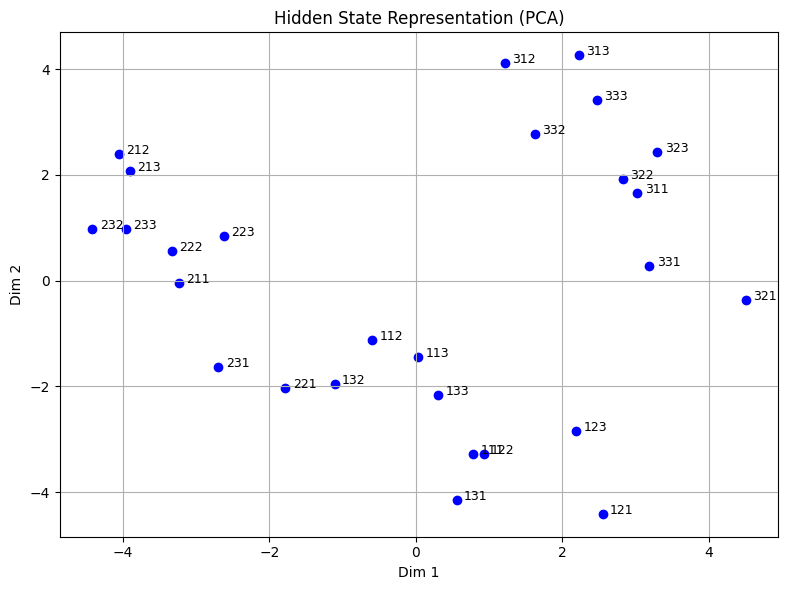

In [8]:
# Call this after training:
visualize_hidden_states(model, method='pca')  # or use method='tsne'

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import random

# Hyperparameters
vocab_size = 3          # Tokens: 0,1,2 (for 1,2,3)
embedding_dim = 8
hidden_size = 40
seq_len = 20            # Length of streaming sequence
context_len = 3         # How many past tokens to reconstruct
batch_size = 1
num_epochs = 1000

# Model components
class RNNEncoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True)

    def forward(self, x, h_prev=None):
        emb = self.embedding(x)
        out, h = self.rnn(emb, h_prev)
        return out, h  # out: [batch, 1, hidden_size], h: [1, batch, hidden_size]

class RNNDecoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, context_len):
        super().__init__()
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.context_len = context_len

    def forward(self, h_context):
        # h_context: [batch, context_len, hidden_size]
        out, _ = self.rnn(h_context)
        logits = self.fc(out)  # [batch, context_len, vocab_size]
        return logits

# Full streaming autoencoder
class StreamingRNNAutoencoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, context_len):
        super().__init__()
        self.encoder = RNNEncoder(vocab_size, embedding_dim, hidden_size)
        self.decoder = RNNDecoder(vocab_size, embedding_dim, hidden_size, context_len)
        self.hidden_size = hidden_size
        self.context_len = context_len

    def forward(self, x):
        batch_size, seq_len = x.size()
        h_prev = torch.zeros(1, batch_size, self.hidden_size)

        losses = []
        criterion = nn.CrossEntropyLoss()
        context_buffer = []

        for t in range(seq_len):
            token_t = x[:, t].unsqueeze(1)  # shape: [batch, 1]
            _, h_prev = self.encoder(token_t, h_prev)
            context_buffer.append(h_prev.squeeze(0).clone())  # [batch, hidden_size]

            if len(context_buffer) < self.context_len:
                continue

            # Collect last `context_len` hidden states
            h_context = torch.stack(context_buffer[-self.context_len:], dim=1)  # [batch, context_len, hidden_size]

            # Get true tokens to predict (previous 3 tokens)
            target_tokens = x[:, max(0, t - self.context_len + 1):t + 1]
            if target_tokens.size(1) < self.context_len:
                # Pad with zeros on the left if not enough context
                pad_len = self.context_len - target_tokens.size(1)
                pad = torch.zeros(batch_size, pad_len, dtype=torch.long)
                target_tokens = torch.cat([pad, target_tokens], dim=1)

            logits = self.decoder(h_context)  # [batch, context_len, vocab_size]
            loss = criterion(logits.view(-1, vocab_size), target_tokens.view(-1))
            losses.append(loss)

        return sum(losses) / len(losses)


# Instantiate model
model = StreamingRNNAutoencoder(vocab_size, embedding_dim, hidden_size, context_len)
optimizer = optim.Adam(model.parameters(), lr=1e-2)

# Training loop
for epoch in range(num_epochs):
    seq = [random.randint(0, vocab_size - 1) for _ in range(seq_len)]
    x = torch.tensor(seq, dtype=torch.long).unsqueeze(0)  # shape: [1, seq_len]

    optimizer.zero_grad()
    loss = model(x)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Epoch 100, Loss: 0.0002
Epoch 200, Loss: 0.0001
Epoch 300, Loss: 0.0001
Epoch 400, Loss: 0.0001
Epoch 500, Loss: 0.0001
Epoch 600, Loss: 0.0000
Epoch 700, Loss: 0.0000
Epoch 800, Loss: 0.0000
Epoch 900, Loss: 0.0000
Epoch 1000, Loss: 0.0000


In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from itertools import product
import numpy as np

def visualize_hidden_states(model, vocab_size=3, seq_len=3, method='pca'):
    model.eval()
    all_hidden_states = []
    all_labels = []

    with torch.no_grad():
        for seq in product(range(vocab_size), repeat=seq_len):
            x = torch.tensor(seq, dtype=torch.long).unsqueeze(0)  # [1, seq_len]
            h_prev = torch.zeros(1, 1, model.hidden_size)
            context_buffer = []

            for t in range(seq_len):
                token_t = x[:, t].unsqueeze(1)  # [1, 1]
                _, h_prev = model.encoder(token_t, h_prev)
                context_buffer.append(h_prev.squeeze(0).clone())  # [1, hidden_size]

            # Grab the last 3 hidden states (entire sequence, since seq_len = 3)
            h_stack = torch.stack(context_buffer[-seq_len:], dim=1)  # [1, 3, hidden_size]
            avg_context = h_stack.mean(dim=1).squeeze(0).numpy()     # [hidden_size]

            all_hidden_states.append(avg_context)
            all_labels.append("".join(str(d + 1) for d in seq))

    X = np.array(all_hidden_states)

    if method == 'tsne':
        reducer = TSNE(n_components=2, perplexity=5, init='random', random_state=42)
    else:
        reducer = PCA(n_components=2)

    X_2d = reducer.fit_transform(X)

    plt.figure(figsize=(8, 6))
    for i, (x, y) in enumerate(X_2d):
        plt.scatter(x, y, c='blue')
        plt.text(x + 0.1, y, all_labels[i], fontsize=9)

    plt.title(f"RNN Context Representation ({method.upper()})")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


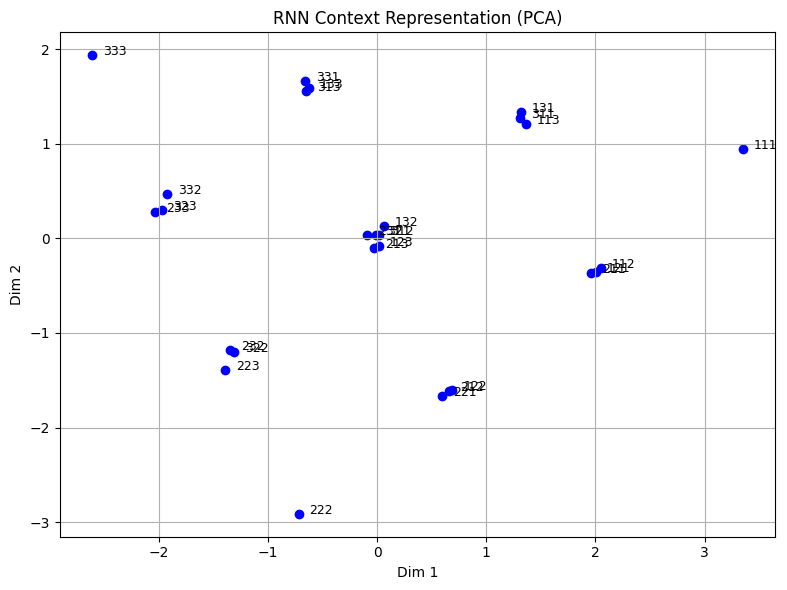

In [11]:
visualize_hidden_states(model, method='pca')   # or method='tsne'
